# AlphaMissense annotation for CFTR variants

Requires `cftr2_results.csv` from `cftr2_scraper.ipynb`.

In [1]:
import os
import re
import gzip
import requests
import pandas as pd

## Step 1. Download AlphaMissense

In [2]:
AM_URL = "https://zenodo.org/records/8208688/files/AlphaMissense_hg38.tsv.gz"
AM_FILE = "AlphaMissense_hg38.tsv.gz"

if os.path.exists(AM_FILE):
    print(f"Already downloaded: {AM_FILE}")
else:
    print("Downloading AlphaMissense hg38 (~1.4 GB)...")
    with requests.get(AM_URL, stream=True, timeout=600) as resp:
        resp.raise_for_status()
        total = 0
        with open(AM_FILE, "wb") as f:
            for chunk in resp.iter_content(chunk_size=10 * 1024 * 1024):
                f.write(chunk)
                total += len(chunk)
                print(f"\r  {total / 1e9:.2f} GB", end="")
    print(f"\nDone. {os.path.getsize(AM_FILE) / 1e9:.2f} GB saved.")

Already downloaded: AlphaMissense_hg38.tsv.gz


## Step 2. Filter to CFTR

In [3]:
CFTR_UNIPROT = "P13569"

rows = []
header = None

print("Filtering to CFTR (P13569)...")
with gzip.open(AM_FILE, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("##"):
            continue
        if line.startswith("#CHROM"):
            header = line.strip().lstrip("#").split("\t")
            continue
        parts = line.strip().split("\t")
        if len(parts) > 5 and parts[5] == CFTR_UNIPROT:
            rows.append(parts)

cftr_am = pd.DataFrame(rows, columns=header)
cftr_am.to_csv("cftr_alphamissense.tsv", sep="\t", index=False)
print(f"Done. Saved {len(cftr_am)} CFTR AlphaMissense scores.")
print(cftr_am[["protein_variant", "am_pathogenicity", "am_class"]].head())

Filtering to CFTR (P13569)...
Done. Saved 9721 CFTR AlphaMissense scores.
  protein_variant am_pathogenicity       am_class
0             Q2E           0.1434  likely_benign
1             Q2K            0.183  likely_benign
2             Q2R           0.1896  likely_benign
3             Q2L           0.2826  likely_benign
4             Q2P           0.2483  likely_benign


## Step 2. Convert three-letter to single-letter amino acid codes

AlphaMissense uses single-letter format (`S13F`). Our VCF variants are three-letter (`Ser13Phe`). Convert to match.

In [4]:
AA3TO1 = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D',
    'Cys': 'C', 'Glu': 'E', 'Gln': 'Q', 'Gly': 'G',
    'His': 'H', 'Ile': 'I', 'Leu': 'L', 'Lys': 'K',
    'Met': 'M', 'Phe': 'F', 'Pro': 'P', 'Ser': 'S',
    'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

def three_to_one(variant: str) -> str | None:
    """Convert Ser13Phe -> S13F. Returns None if conversion fails."""
    m = re.match(r'([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', variant)
    if not m:
        return None
    ref, pos, alt = m.groups()
    if ref not in AA3TO1 or alt not in AA3TO1:
        return None
    return f"{AA3TO1[ref]}{pos}{AA3TO1[alt]}"

# Load results and convert
result = pd.read_csv("cftr2_results.csv")
result['am_variant'] = result['variant'].apply(three_to_one)

failed = result['am_variant'].isna().sum()
print(f"Converted: {len(result) - failed} / {len(result)}")
print(f"Failed   : {failed}")
print()
print(result[['variant', 'am_variant']].head(5))

Converted: 2909 / 3220
Failed   : 311

    variant am_variant
0  Ser13Phe       S13F
1  Arg31Cys       R31C
2  Arg31Leu       R31L
3  Ser42Phe       S42F
4  Asp44Gly       D44G


In [5]:
cftr_am = pd.read_csv("cftr_alphamissense.tsv", sep="\t")

result = result.merge(
    cftr_am[["protein_variant", "am_pathogenicity", "am_class"]],
    left_on="am_variant",
    right_on="protein_variant",
    how="left"
).drop(columns=["protein_variant"])

result.to_csv("cftr2_results_annotated.csv", index=False)

print(f"AlphaMissense scored : {result['am_pathogenicity'].notna().sum()}")
print(f"Not scored           : {result['am_pathogenicity'].isna().sum()}")
print()
print(result[["variant", "am_variant", "determination_2026", "am_pathogenicity", "am_class"]].head(10))


AlphaMissense scored : 3161
Not scored           : 555

    variant am_variant            determination_2026  am_pathogenicity  \
0  Ser13Phe       S13F                    CF-causing            0.7624   
1  Arg31Cys       R31C                Non CF-causing            0.1079   
2  Arg31Leu       R31L  Varying clinical consequence            0.1732   
3  Ser42Phe       S42F   No interpretation available            0.1165   
4  Asp44Gly       D44G                           NaN            0.5282   
5  Ser50Tyr       S50Y                           NaN            0.8651   
6  Trp57Gly       W57G                    CF-causing            0.9560   
7  Pro67Leu       P67L                    CF-causing            0.6516   
8  Arg74Trp       R74W  Varying clinical consequence            0.1405   
9  Arg75Gln       R75Q                Non CF-causing            0.1994   

            am_class  
0  likely_pathogenic  
1      likely_benign  
2      likely_benign  
3      likely_benign  
4          amb

In [6]:
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# Only use variants with both CFTR2 determination and AM score
validated = result[
    result["determination_2026"].notna() &
    result["am_pathogenicity"].notna()
].copy()

# Binary label: CF-causing = 1, Non CF-causing = 0, drop Varying/No interpretation
binary = validated[
    validated["determination_2026"].isin(["CF-causing", "Non CF-causing"])
].copy()

binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

auc = roc_auc_score(binary["label"], binary["am_pathogenicity"])
print(f"Variants used : {len(binary)}")
print(f"CF-causing    : {binary['label'].sum()}")
print(f"Non CF-causing: {(binary['label'] == 0).sum()}")
print(f"AUC           : {auc:.3f}")
print()
print(classification_report(
    binary["label"],
    (binary["am_pathogenicity"] >= 0.5).astype(int),
    target_names=["Non CF-causing", "CF-causing"]
))


Variants used : 292
CF-causing    : 253
Non CF-causing: 39
AUC           : 0.946

                precision    recall  f1-score   support

Non CF-causing       0.77      0.77      0.77        39
    CF-causing       0.96      0.96      0.96       253

      accuracy                           0.94       292
     macro avg       0.87      0.87      0.87       292
  weighted avg       0.94      0.94      0.94       292



In [7]:
unmatched = result[
    result["determination_2026"].isna() &
    result["am_pathogenicity"].notna()
].copy()

print(f"Unmatched variants with AM score: {len(unmatched)}")
print()
print(unmatched["am_class"].value_counts())
print()

# High-priority: no CFTR2 classification but AlphaMissense calls likely_pathogenic
flagged = unmatched[unmatched["am_class"] == "likely_pathogenic"].sort_values(
    "am_pathogenicity", ascending=False
)

print(f"Flagged as likely_pathogenic: {len(flagged)}")
print()
print(flagged[["variant", "am_variant", "am_pathogenicity"]].head(20))

flagged.to_csv("flagged_unclassified.csv", index=False)
print("\nSaved to flagged_unclassified.csv")


Unmatched variants with AM score: 2411

am_class
likely_benign        1349
likely_pathogenic     705
ambiguous             357
Name: count, dtype: int64

Flagged as likely_pathogenic: 705

         variant am_variant  am_pathogenicity
1507   Leu526Pro      L526P            0.9965
3171  Leu1242Pro     L1242P            0.9945
1646   Leu578Pro      L578P            0.9935
432     Pro99Arg       P99R            0.9933
3484  Leu1368Pro     L1368P            0.9929
3001  Arg1162Pro     R1162P            0.9923
2951  Trp1145Arg     W1145R            0.9920
2950  Trp1145Arg     W1145R            0.9920
2629  Gly1003Arg     G1003R            0.9908
2630  Gly1003Arg     G1003R            0.9908
2821  Arg1097Pro     R1097P            0.9900
1651   Asp579Val      D579V            0.9897
1006   Phe337Leu      F337L            0.9878
1008   Phe337Leu      F337L            0.9878
1007   Phe337Leu      F337L            0.9878
1027   Arg347Ser      R347S            0.9877
2688  Phe1033Leu     F1033L  

In [8]:
flagged = flagged.drop_duplicates(subset=["am_variant"]).sort_values(
    "am_pathogenicity", ascending=False
)

print(f"After dedup: {len(flagged)} unique likely_pathogenic variants")
print()
print(flagged[["variant", "am_variant", "am_pathogenicity"]].head(20))

flagged.to_csv("flagged_unclassified.csv", index=False)
print("Saved to flagged_unclassified.csv")


After dedup: 546 unique likely_pathogenic variants

         variant am_variant  am_pathogenicity
1507   Leu526Pro      L526P            0.9965
3171  Leu1242Pro     L1242P            0.9945
1646   Leu578Pro      L578P            0.9935
432     Pro99Arg       P99R            0.9933
3484  Leu1368Pro     L1368P            0.9929
3001  Arg1162Pro     R1162P            0.9923
2951  Trp1145Arg     W1145R            0.9920
2629  Gly1003Arg     G1003R            0.9908
2821  Arg1097Pro     R1097P            0.9900
1651   Asp579Val      D579V            0.9897
1006   Phe337Leu      F337L            0.9878
1027   Arg347Ser      R347S            0.9877
2688  Phe1033Leu     F1033L            0.9874
1503   Cys524Tyr      C524Y            0.9873
3425  Leu1346Pro     L1346P            0.9873
2750  Leu1062Pro     L1062P            0.9868
3168  Gly1241Asp     G1241D            0.9861
2926  Ala1136Pro     A1136P            0.9857
2911  Gly1130Arg     G1130R            0.9847
2439   Asp924His      D924H 

In [9]:
# Cross flagged variants with allele frequency
flagged_freq = result[
    result["determination_2026"].isna() &
    (result["am_class"] == "likely_pathogenic")
].drop_duplicates(subset=["am_variant"]).copy()

flagged_freq["allele_frequency"] = pd.to_numeric(flagged_freq["allele_frequency"], errors="coerce")

flagged_freq = flagged_freq.sort_values("allele_frequency", ascending=False)

print(f"Flagged likely_pathogenic with frequency data: {flagged_freq['allele_frequency'].notna().sum()}")
print(f"No frequency data: {flagged_freq['allele_frequency'].isna().sum()}")
print()
print(flagged_freq[["variant", "am_variant", "am_pathogenicity", "allele_frequency"]].head(20))

flagged_freq.to_csv("flagged_prioritised.csv", index=False)
print("\nSaved to flagged_prioritised.csv")


Flagged likely_pathogenic with frequency data: 0
No frequency data: 546

        variant am_variant  am_pathogenicity  allele_frequency
5      Ser50Tyr       S50Y            0.8651               NaN
41    Met244Lys      M244K            0.7122               NaN
64    Gln353His      Q353H            0.8182               NaN
125   Arg766Met      R766M            0.7923               NaN
161  Gln1071Pro     Q1071P            0.7210               NaN
193  Val1397Glu     V1397E            0.9252               NaN
202     Ser4Leu        S4L            0.6087               NaN
203     Ser4Trp        S4W            0.7271               NaN
205     Pro5Ser        P5S            0.5872               NaN
207     Pro5Arg        P5R            0.6024               NaN
210     Glu7Lys        E7K            0.6316               NaN
223    Ser13Tyr       S13Y            0.6720               NaN
237    Phe17Ser       F17S            0.8468               NaN
238    Leu15His       L15H            0.6553 

In [10]:
# Check what frequency fields VEP added to the VCF
with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as f:
    for line in f:
        if line.startswith("##INFO=<ID=CSQ"):
            print(line.strip())
            break

# Also check a sample data line
with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as f:
    for line in f:
        if not line.startswith("#"):
            print(line.strip()[:500])
            break


##INFO=<ID=CSQ,Number=.,Type=String,Description="Consequence annotations from Ensembl VEP. Format: Allele|Consequence|IMPACT|SYMBOL|Gene|Feature_type|Feature|BIOTYPE|EXON|INTRON|HGVSc|HGVSp|cDNA_position|CDS_position|Protein_position|Amino_acids|Codons|Existing_variation|REF_ALLELE|UPLOADED_ALLELE|DISTANCE|STRAND|FLAGS|SYMBOL_SOURCE|HGNC_ID|MANE|MANE_SELECT|MANE_PLUS_CLINICAL|TSL|APPRIS|ENSP|SIFT|PolyPhen|HGVS_OFFSET|AF|CLIN_SIG|SOMATIC|PHENO|PUBMED|MOTIF_NAME|MOTIF_POS|HIGH_INF_POS|MOTIF_SCORE_CHANGE|TRANSCRIPTION_FACTORS">
7	117480132	53845	C	T	.	.	ALLELEID=68512;CLNDISDB=MONDO:MONDO:0008887,MedGen:C2749757,OMIM:211400,Orphanet:60033|MedGen:C3661900|MONDO:MONDO:7770004,MedGen:C5924204|MONDO:MONDO:0009061,MedGen:C0010674,OMIM:219700,Orphanet:586|MONDO:MONDO:0010178,MedGen:C0403814,OMIM:277180,Orphanet:48;CLNDN=Bronchiectasis_with_or_without_elevated_sweat_chloride_1|not_provided|CFTR-related_disorder|Cystic_fibrosis|Congenital_bilateral_aplasia_of_vas_deferens_from_CFTR_mutation;CLNHG

In [11]:
import re

csq_pattern = re.compile(r'CSQ=([^;]+)')
protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')
AF_INDEX = 34

variant_af = {}

with open("All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        csq_match = csq_pattern.search(line)
        if not csq_match:
            continue
        for transcript in csq_match.group(1).split(","):
            fields = transcript.split("|")
            if len(fields) <= AF_INDEX:
                continue
            prot_match = protein_pattern.search(fields[11])
            if not prot_match:
                continue
            name = prot_match.group(1)
            af_str = fields[AF_INDEX]
            if af_str and af_str != ".":
                try:
                    af_val = float(af_str)
                    if name not in variant_af or af_val > variant_af[name]:
                        variant_af[name] = af_val
                except ValueError:
                    pass

print(f"Variants with AF from VCF: {len(variant_af)}")
print(list(variant_af.items())[:5])


Variants with AF from VCF: 117
[('Arg31Cys', 0.0014), ('Arg74Trp', 0.0054), ('Arg75Gln', 0.0064), ('Ile148Thr', 0.0014), ('Arg258Gly', 0.0002)]


In [12]:
# Map AF from VCF onto flagged variants
flagged_freq["vcf_af"] = flagged_freq["variant"].map(variant_af)

with_freq = flagged_freq[flagged_freq["vcf_af"].notna()].sort_values("vcf_af", ascending=False)
without_freq = flagged_freq[flagged_freq["vcf_af"].isna()]

print(f"Flagged likely_pathogenic with population frequency: {len(with_freq)}")
print(f"No frequency data (too rare for gnomAD)           : {len(without_freq)}")
print()
print(with_freq[["variant", "am_pathogenicity", "vcf_af"]].to_string())


Flagged likely_pathogenic with population frequency: 7
No frequency data (too rare for gnomAD)           : 539

         variant  am_pathogenicity  vcf_af
2595   Leu986Pro            0.8685  0.0004
305     Leu49Pro            0.9757  0.0002
447    Arg104Gly            0.8448  0.0002
1043   Pro355Leu            0.8580  0.0002
1819   Phe650Leu            0.8455  0.0002
2734  His1054Gln            0.9010  0.0002
2820  Arg1097Cys            0.6513  0.0002


In [13]:
priority = with_freq[["variant", "am_variant", "am_pathogenicity", "vcf_af"]].copy()
priority = priority.sort_values("am_pathogenicity", ascending=False)
priority.to_csv("priority_candidates.csv", index=False)
print("Saved to priority_candidates.csv")
print()
print(priority.to_string(index=False))


Saved to priority_candidates.csv

   variant am_variant  am_pathogenicity  vcf_af
  Leu49Pro       L49P            0.9757  0.0002
His1054Gln     H1054Q            0.9010  0.0002
 Leu986Pro      L986P            0.8685  0.0004
 Pro355Leu      P355L            0.8580  0.0002
 Phe650Leu      F650L            0.8455  0.0002
 Arg104Gly      R104G            0.8448  0.0002
Arg1097Cys     R1097C            0.6513  0.0002


In [14]:
varying = result[result["determination_2026"] == "Varying clinical consequence"].copy()

print(f"Total varying clinical consequence: {len(varying)}")
print(f"With AlphaMissense score          : {varying['am_pathogenicity'].notna().sum()}")
print()
print(varying["am_class"].value_counts())
print()
print(varying[["variant", "am_pathogenicity", "am_class"]].sort_values(
    "am_pathogenicity", ascending=False
).to_string(index=False))


Total varying clinical consequence: 82
With AlphaMissense score          : 82

am_class
likely_pathogenic    50
ambiguous            19
likely_benign        13
Name: count, dtype: int64

   variant  am_pathogenicity          am_class
 Asp979Ala            0.9928 likely_pathogenic
 Gly314Glu            0.9849 likely_pathogenic
Thr1246Ile            0.9803 likely_pathogenic
Phe1099Leu            0.9789 likely_pathogenic
Phe1099Leu            0.9789 likely_pathogenic
Phe1099Leu            0.9789 likely_pathogenic
Gln1291His            0.9749 likely_pathogenic
Gln1291His            0.9749 likely_pathogenic
 Asp579Gly            0.9706 likely_pathogenic
Phe1074Leu            0.9698 likely_pathogenic
Phe1074Leu            0.9698 likely_pathogenic
Phe1074Leu            0.9698 likely_pathogenic
Ile1366Thr            0.9637 likely_pathogenic
 Cys491Arg            0.9628 likely_pathogenic
 Asp993Ala            0.9608 likely_pathogenic
 Ala309Asp            0.9589 likely_pathogenic
 Arg933Gly    

In [15]:
varying_clean = varying.drop_duplicates(subset=["variant"]).sort_values(
    "am_pathogenicity", ascending=False
)

varying_clean[["variant", "am_pathogenicity", "am_class"]].to_csv(
    "varying_consequence_am.csv", index=False
)

print(f"Unique varying variants: {len(varying_clean)}")
print()
print(f"likely_pathogenic : {(varying_clean['am_class'] == 'likely_pathogenic').sum()}")
print(f"ambiguous         : {(varying_clean['am_class'] == 'ambiguous').sum()}")
print(f"likely_benign     : {(varying_clean['am_class'] == 'likely_benign').sum()}")


Unique varying variants: 72

likely_pathogenic : 41
ambiguous         : 19
likely_benign     : 12


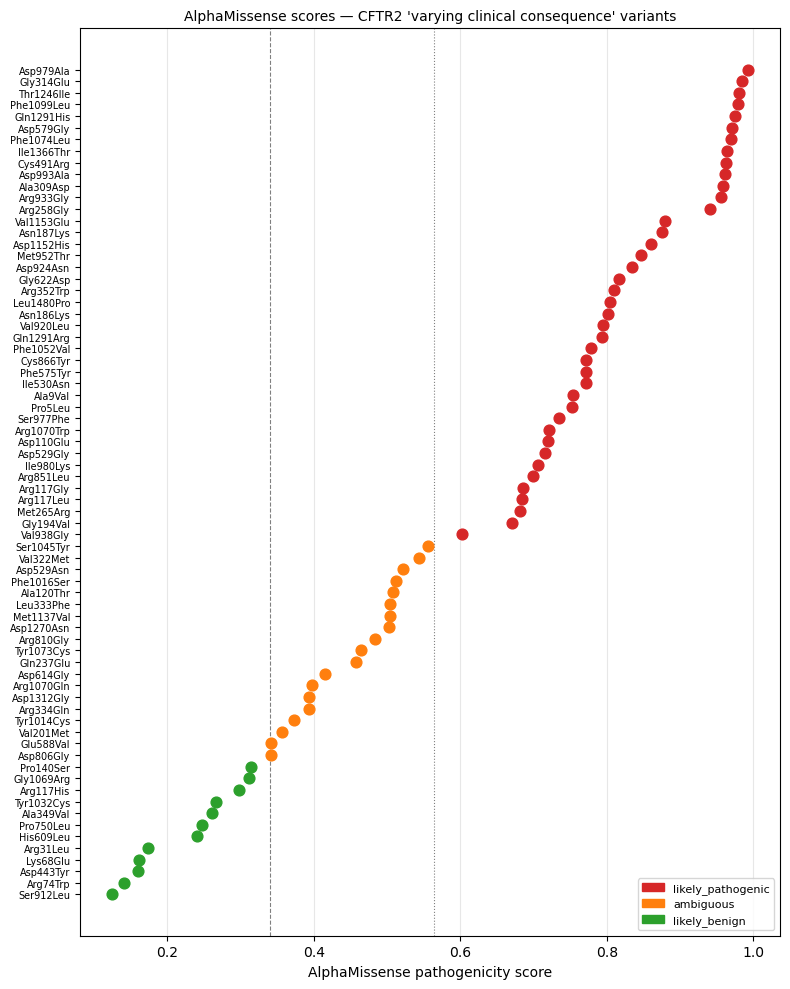

Saved to varying_consequence_plot.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = {
    "likely_pathogenic": "#d62728",
    "ambiguous": "#ff7f0e",
    "likely_benign": "#2ca02c"
}

df_plot = varying_clean.sort_values("am_pathogenicity")

fig, ax = plt.subplots(figsize=(8, 10))

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.scatter(row["am_pathogenicity"], i,
               color=colors[row["am_class"]], s=60, zorder=3)

ax.axvline(0.34, color="grey", linestyle="--", linewidth=0.8, label="benign threshold (0.34)")
ax.axvline(0.564, color="grey", linestyle=":", linewidth=0.8, label="pathogenic threshold (0.564)")

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot["variant"], fontsize=7)
ax.set_xlabel("AlphaMissense pathogenicity score")
ax.set_title("AlphaMissense scores — CFTR2 'varying clinical consequence' variants", fontsize=10)

patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("varying_consequence_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to varying_consequence_plot.png")


In [19]:
import time

CLINVAR_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

def query_clinvar(variant: str) -> dict:
    """Query ClinVar for a variant by name and return significance if found."""
    params = {
        "db": "clinvar",
        "term": f"{variant}[varname] AND CFTR[gene]",
        "retmode": "json"
    }
    resp = requests.get(CLINVAR_URL, params=params, timeout=10)
    data = resp.json()
    count = int(data["esearchresult"]["count"])
    ids = data["esearchresult"]["idlist"]
    return {"variant": variant, "clinvar_hits": count, "ids": ids}

results_cv = []
priority_candidates = pd.read_csv("priority_candidates.csv")
for v in priority_candidates["variant"]:
    r = query_clinvar(v)
    print(f"{v}: {r['clinvar_hits']} hits")
    results_cv.append(r)
    time.sleep(0.4)

print()



Leu49Pro: 1 hits
His1054Gln: 1 hits
Leu986Pro: 1 hits
Pro355Leu: 1 hits
Phe650Leu: 1 hits
Arg104Gly: 1 hits
Arg1097Cys: 1 hits



In [20]:
CLINVAR_SUMMARY = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

def get_clinvar_significance(clinvar_id: str) -> str:
    params = {
        "db": "clinvar",
        "id": clinvar_id,
        "retmode": "json"
    }
    resp = requests.get(CLINVAR_SUMMARY, params=params, timeout=10)
    data = resp.json()
    try:
        result = data["result"][clinvar_id]
        sig = result["clinical_significance"]["description"]
        review = result["clinical_significance"]["review_status"]
        return f"{sig} ({review})"
    except Exception:
        return "unknown"

for r in results_cv:
    if r["ids"]:
        sig = get_clinvar_significance(r["ids"][0])
        print(f"{r['variant']:15} {sig}")
    time.sleep(0.4)


Leu49Pro        unknown
His1054Gln      unknown
Leu986Pro       unknown
Pro355Leu       unknown
Phe650Leu       unknown
Arg104Gly       unknown
Arg1097Cys      unknown


In [21]:
params = {
    "db": "clinvar",
    "id": results_cv[0]["ids"][0],
    "retmode": "json"
}
resp = requests.get(CLINVAR_SUMMARY, params=params, timeout=10)
import json
print(json.dumps(resp.json(), indent=2)[:2000])


{
  "header": {
    "type": "esummary",
    "version": "0.3"
  },
  "result": {
    "uids": [
      "3390562"
    ],
    "3390562": {
      "uid": "3390562",
      "obj_type": "single nucleotide variant",
      "accession": "VCV003390562",
      "accession_version": "VCV003390562.1",
      "title": "NM_000492.4(CFTR):c.146T>C (p.Leu49Pro)",
      "variation_set": [
        {
          "measure_id": "3549692",
          "variation_xrefs": [],
          "variation_name": "NM_000492.4(CFTR):c.146T>C (p.Leu49Pro)",
          "cdna_change": "c.146T>C",
          "aliases": [],
          "variation_loc": [
            {
              "status": "current",
              "assembly_name": "GRCh38",
              "chr": "7",
              "band": "7q31.2",
              "start": "117504345",
              "stop": "117504345",
              "inner_start": "",
              "inner_stop": "",
              "outer_start": "",
              "outer_stop": "",
              "display_start": "117504345",

In [22]:
print(json.dumps(resp.json()["result"]["3390562"], indent=2)[1500:])


: [],
      "variant_type": "single nucleotide variant",
      "canonical_spdi": "NC_000007.14:117504344:T:C",
      "common_name": ""
    }
  ],
  "supporting_submissions": {
    "scv": [
      "SCV005437458"
    ],
    "rcv": [
      "RCV004812732"
    ]
  },
  "germline_classification": {
    "description": "Uncertain significance",
    "last_evaluated": "2024/06/14 00:00",
    "review_status": "criteria provided, single submitter",
    "fda_recognized_database": "",
    "trait_set": [
      {
        "trait_xrefs": [
          {
            "db_source": "MedGen",
            "db_id": "C3661900"
          }
        ],
        "trait_name": "not provided"
      }
    ]
  },
  "clinical_impact_classification": {
    "description": "",
    "last_evaluated": "1/01/01 00:00",
    "review_status": "",
    "fda_recognized_database": "",
    "trait_set": []
  },
  "oncogenicity_classification": {
    "description": "",
    "last_evaluated": "1/01/01 00:00",
    "review_status": "",
    "fda

In [23]:
def get_clinvar_significance(clinvar_id: str) -> str:
    params = {
        "db": "clinvar",
        "id": clinvar_id,
        "retmode": "json"
    }
    resp = requests.get(CLINVAR_SUMMARY, params=params, timeout=10)
    data = resp.json()
    try:
        result = data["result"][clinvar_id]
        sig = result["germline_classification"]["description"]
        review = result["germline_classification"]["review_status"]
        last_eval = result["germline_classification"]["last_evaluated"]
        return f"{sig} | {review} | {last_eval}"
    except Exception:
        return "unknown"

for r in results_cv:
    if r["ids"]:
        sig = get_clinvar_significance(r["ids"][0])
        print(f"{r['variant']:15} {sig}")
    time.sleep(0.4)


Leu49Pro        Uncertain significance | criteria provided, single submitter | 2024/06/14 00:00
His1054Gln      Uncertain significance | criteria provided, multiple submitters, no conflicts | 2025/08/27 00:00
Leu986Pro       Conflicting classifications of pathogenicity | criteria provided, conflicting classifications | 2025/12/30 00:00
Pro355Leu       Uncertain significance | criteria provided, multiple submitters, no conflicts | 2023/04/19 00:00
Phe650Leu       Uncertain significance | criteria provided, multiple submitters, no conflicts | 2025/11/24 00:00
Arg104Gly       Uncertain significance | criteria provided, single submitter | 2025/05/31 00:00
Arg1097Cys      Conflicting classifications of pathogenicity | criteria provided, conflicting classifications | 2026/02/03 00:00


In [24]:
final = priority_candidates.copy()
final["clinvar_significance"] = [
    "Uncertain significance",
    "Uncertain significance", 
    "Conflicting classifications of pathogenicity",
    "Uncertain significance",
    "Uncertain significance",
    "Uncertain significance",
    "Conflicting classifications of pathogenicity"
]
final["clinvar_review"] = [
    "single submitter",
    "multiple submitters, no conflicts",
    "conflicting classifications",
    "multiple submitters, no conflicts",
    "multiple submitters, no conflicts",
    "single submitter",
    "conflicting classifications"
]
final.to_csv("priority_candidates_clinvar.csv", index=False)
print(final[["variant", "am_pathogenicity", "vcf_af", "clinvar_significance"]].to_string(index=False))


   variant  am_pathogenicity  vcf_af                         clinvar_significance
  Leu49Pro            0.9757  0.0002                       Uncertain significance
His1054Gln            0.9010  0.0002                       Uncertain significance
 Leu986Pro            0.8685  0.0004 Conflicting classifications of pathogenicity
 Pro355Leu            0.8580  0.0002                       Uncertain significance
 Phe650Leu            0.8455  0.0002                       Uncertain significance
 Arg104Gly            0.8448  0.0002                       Uncertain significance
Arg1097Cys            0.6513  0.0002 Conflicting classifications of pathogenicity


In [25]:
all_variants = pd.read_csv("cftr2_results.csv")
excluded = all_variants[all_variants["variant"].apply(three_to_one).isna()].copy()

print(f"Total excluded: {len(excluded)}")
print()

# Check what types they are
print(excluded["variant"].head(30).to_string())


Total excluded: 311

165      Gln2Ter
173      Ser4Ter
180      Glu7Ter
195     Lys14Ter
211     Trp19Ter
214     Leu24Ter
221     Gly27Ter
225     Arg29Ter
227     Gln30Ter
234     Glu33Ter
244     Tyr38Ter
245     Gln39Ter
267     Lys52Ter
276     Glu56Ter
279     Trp57Ter
287     Glu60Ter
295     Ser63Ter
315     Arg75Ter
325     Trp79Ter
337     Tyr84Ter
339     Gly85Ter
350     Leu88Ter
354     Leu90Ter
355     Glu92Ter
361     Lys95Ter
365     Gln98Ter
375    Leu101Ter
380    Gly103Ter
390    Ala107Ter
397    Tyr109Ter


In [27]:
cftr2_data = pd.read_excel("cftr2_variants.xlsx", header=11)
print(f"Columns: {len(cftr2_data.columns)}")
print(cftr2_data.columns.tolist())


Columns: 9
['Variant legacy name', 'Variant protein name', 'Variant cDNA name', 'Variant alternative names (other names that may have been used in the past)', '# alleles reported in CFTR2', 'Allele frequency in CFTR2* (of 211106 identified alleles)', 'Variant final determination 25 September 2024 (previous version)', 'Variant final determination 30 January 2026 (current version)', 'Change from previous?']


In [29]:
nonsense_matched = excluded.drop(columns=["determination_2026"], errors="ignore").merge(
    cftr2_data[["protein_name", "determination_2026"]],
    on="protein_name", how="left"
)

print(f"In CFTR2     : {nonsense_matched['determination_2026'].notna().sum()}")
print(f"Not in CFTR2 : {nonsense_matched['determination_2026'].isna().sum()}")
print()
print(nonsense_matched["determination_2026"].value_counts())


In CFTR2     : 0
Not in CFTR2 : 311

Series([], Name: count, dtype: int64)


In [30]:
# See how CFTR2 represents stop codons
stop_codons = cftr2_data[cftr2_data["protein_name"].str.contains(r"Ter|\*|[A-Z][a-z]{2}\d+X", na=False)]
print(stop_codons[["legacy_name", "protein_name"]].head(10))
print()
# Also check what our excluded variants look like
print(excluded["protein_name"].head(5))


   legacy_name protein_name
1        G542X    p.Gly542X
4       W1282X   p.Trp1282X
8        R553X    p.Arg553X
14      R1162X   p.Arg1162X
29   1677delTA    p.Tyr515X
34       Q493X    p.Gln493X
37        E60X     p.Glu60X
42      Y1092X   p.Tyr1092X
43      R1158X   p.Arg1158X
47    2143delT    p.Leu671X

165     p.Gln2Ter
173     p.Ser4Ter
180     p.Glu7Ter
195    p.Lys14Ter
211    p.Trp19Ter
Name: protein_name, dtype: object


In [31]:
excluded["protein_name"] = excluded["protein_name"].str.replace("Ter", "X")

nonsense_matched = excluded.drop(columns=["determination_2026"], errors="ignore").merge(
    cftr2_data[["protein_name", "determination_2026"]],
    on="protein_name", how="left"
)

print(f"In CFTR2     : {nonsense_matched['determination_2026'].notna().sum()}")
print(f"Not in CFTR2 : {nonsense_matched['determination_2026'].isna().sum()}")
print()
print(nonsense_matched["determination_2026"].value_counts())


In CFTR2     : 232
Not in CFTR2 : 89

determination_2026
CF-causing                      225
No interpretation available       5
Varying clinical consequence      2
Name: count, dtype: int64


In [32]:
# The 2 varying clinical consequence nonsense variants are unusual
varying_nonsense = nonsense_matched[
    nonsense_matched["determination_2026"] == "Varying clinical consequence"
][["variant", "protein_name", "determination_2026"]]
print("Varying clinical consequence nonsense variants:")
print(varying_nonsense.to_string(index=False))

print()

# The 89 not in CFTR2
unclassified_nonsense = nonsense_matched[nonsense_matched["determination_2026"].isna()]
print(f"Unclassified nonsense variants: {len(unclassified_nonsense)}")
print(unclassified_nonsense["variant"].head(10).to_string())


Varying clinical consequence nonsense variants:
   variant protein_name           determination_2026
Ser1455Ter   p.Ser1455X Varying clinical consequence
Gln1476Ter   p.Gln1476X Varying clinical consequence

Unclassified nonsense variants: 89
2       Glu7Ter
7      Arg29Ter
16     Ser63Ter
22     Leu90Ter
24     Lys95Ter
28    Ala107Ter
33    Leu127Ter
34    Gly149Ter
39    Ser168Ter
41    Lys190Ter


In [33]:
nonsense_matched.to_csv("nonsense_variants_cftr2.csv", index=False)

print("Summary:")
print(f"Total nonsense variants in VCF : 311")
print(f"Matched to CFTR2               : 232")
print(f"  CF-causing                   : 225")
print(f"  Varying clinical consequence : 2  (Ser1455Ter, Gln1476Ter — near C-terminus)")
print(f"  No interpretation available  : 5")
print(f"Not in CFTR2                   : 89")


Summary:
Total nonsense variants in VCF : 311
Matched to CFTR2               : 232
  CF-causing                   : 225
  Varying clinical consequence : 2  (Ser1455Ter, Gln1476Ter — near C-terminus)
  No interpretation available  : 5
Not in CFTR2                   : 89


In [34]:
# CFTR domain boundaries (canonical, NM_000492.4)
domains = [
    ("MSD1",  1,   394),
    ("NBD1",  395, 646),
    ("R-domain", 647, 835),
    ("MSD2",  836, 1172),
    ("NBD2",  1173, 1480),
]

def get_domain(position: int) -> str:
    for name, start, end in domains:
        if start <= position <= end:
            return name
    return "unknown"

# Extract position from variant name e.g. Asp979Ala -> 979
import re

varying_pathogenic = varying_clean[varying_clean["am_class"] == "likely_pathogenic"].copy()
varying_pathogenic["position"] = varying_pathogenic["variant"].str.extract(r'(\d+)').astype(int)
varying_pathogenic["domain"] = varying_pathogenic["position"].apply(get_domain)

print(varying_pathogenic["domain"].value_counts())
print()
print(varying_pathogenic[["variant", "position", "domain", "am_pathogenicity"]].sort_values("position").to_string(index=False))


domain
MSD2    17
MSD1    13
NBD1     6
NBD2     5
Name: count, dtype: int64

   variant  position domain  am_pathogenicity
   Pro5Leu         5   MSD1            0.7529
   Ala9Val         9   MSD1            0.7544
 Asp110Glu       110   MSD1            0.7201
 Arg117Leu       117   MSD1            0.6843
 Arg117Gly       117   MSD1            0.6851
 Asn186Lys       186   MSD1            0.8013
 Asn187Lys       187   MSD1            0.8752
 Gly194Val       194   MSD1            0.6701
 Arg258Gly       258   MSD1            0.9409
 Met265Arg       265   MSD1            0.6810
 Ala309Asp       309   MSD1            0.9589
 Gly314Glu       314   MSD1            0.9849
 Arg352Trp       352   MSD1            0.8098
 Cys491Arg       491   NBD1            0.9628
 Asp529Gly       529   NBD1            0.7158
 Ile530Asn       530   NBD1            0.7708
 Phe575Tyr       575   NBD1            0.7710
 Asp579Gly       579   NBD1            0.9706
 Gly622Asp       622   NBD1            0.8162
 A

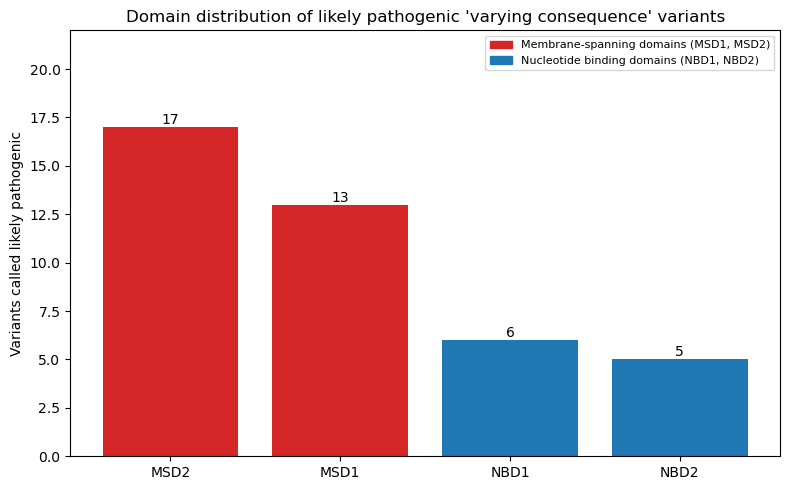

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

domain_counts = varying_pathogenic["domain"].value_counts()
colors_d = {"MSD1": "#d62728", "MSD2": "#d62728", "NBD1": "#1f77b4", "NBD2": "#1f77b4", "R-domain": "#2ca02c"}
bars = ax.bar(domain_counts.index, domain_counts.values,
              color=[colors_d.get(d, "grey") for d in domain_counts.index])

ax.set_ylabel("Variants called likely pathogenic")
ax.set_title("Domain distribution of likely pathogenic 'varying consequence' variants")
ax.bar_label(bars)
ax.set_ylim(0, 22)

import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color="#d62728", label="Membrane-spanning domains (MSD1, MSD2)"),
    mpatches.Patch(color="#1f77b4", label="Nucleotide binding domains (NBD1, NBD2)")
]
ax.legend(handles=legend, fontsize=8)
plt.tight_layout()
plt.savefig("domain_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


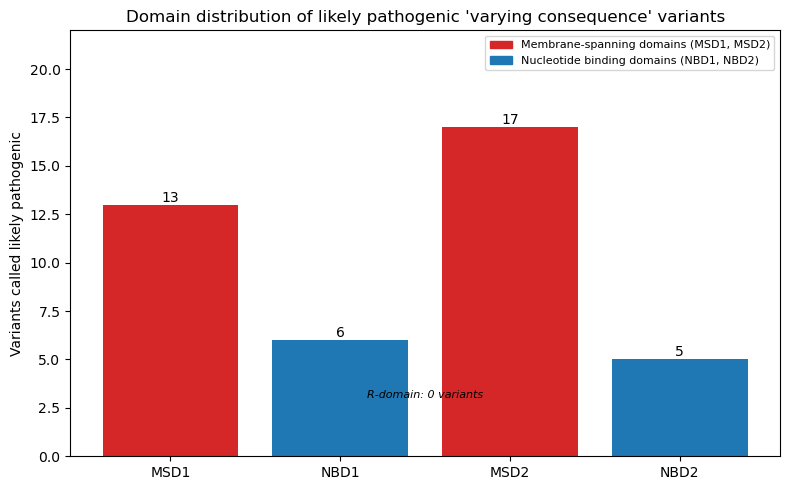

In [37]:
domain_order = ["MSD1", "NBD1", "MSD2", "NBD2"]
counts_ordered = varying_pathogenic["domain"].value_counts().reindex(domain_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts_ordered.index, counts_ordered.values,
              color=[colors_d.get(d, "grey") for d in counts_ordered.index])

ax.set_ylabel("Variants called likely pathogenic")
ax.set_title("Domain distribution of likely pathogenic 'varying consequence' variants")
ax.bar_label(bars)
ax.set_ylim(0, 22)

legend = [
    mpatches.Patch(color="#d62728", label="Membrane-spanning domains (MSD1, MSD2)"),
    mpatches.Patch(color="#1f77b4", label="Nucleotide binding domains (NBD1, NBD2)")
]
ax.legend(handles=legend, fontsize=8)
ax.annotate("R-domain: 0 variants", xy=(1.5, 3), fontsize=8, color="black", ha="center",
            style="italic")

plt.tight_layout()
plt.savefig("domain_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


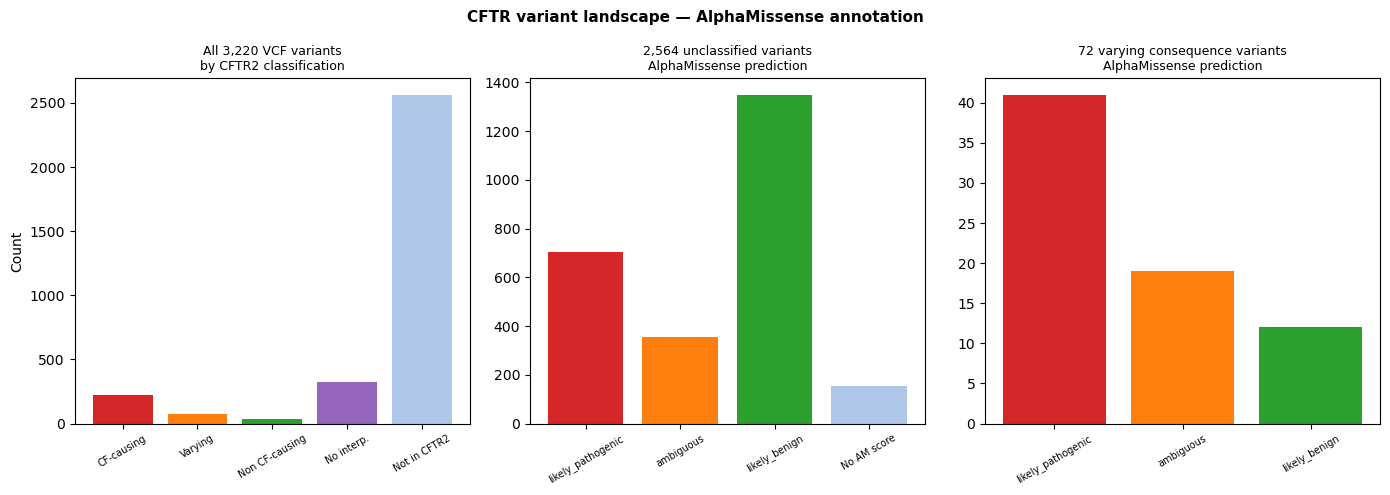

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Chart 1: Overall variant breakdown
labels1 = ["CF-causing", "Varying", "Non CF-causing", "No interp.", "Not in CFTR2"]
sizes1 = [226, 72, 33, 325, 2564]
colors1 = ["#d62728", "#ff7f0e", "#2ca02c", "#9467bd", "#aec7e8"]
axes[0].bar(labels1, sizes1, color=colors1)
axes[0].set_title("All 3,220 VCF variants\nby CFTR2 classification", fontsize=9)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", labelsize=7, rotation=30)

# Chart 2: AlphaMissense on unclassified
labels2 = ["likely_pathogenic", "ambiguous", "likely_benign", "No AM score"]
sizes2 = [705, 357, 1349, 153]
colors2 = ["#d62728", "#ff7f0e", "#2ca02c", "#aec7e8"]
axes[1].bar(labels2, sizes2, color=colors2)
axes[1].set_title("2,564 unclassified variants\nAlphaMissense prediction", fontsize=9)
axes[1].tick_params(axis="x", labelsize=7, rotation=30)

# Chart 3: AlphaMissense on varying consequence
labels3 = ["likely_pathogenic", "ambiguous", "likely_benign"]
sizes3 = [41, 19, 12]
colors3 = ["#d62728", "#ff7f0e", "#2ca02c"]
axes[2].bar(labels3, sizes3, color=colors3)
axes[2].set_title("72 varying consequence variants\nAlphaMissense prediction", fontsize=9)
axes[2].tick_params(axis="x", labelsize=7, rotation=30)

plt.suptitle("CFTR variant landscape — AlphaMissense annotation", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()


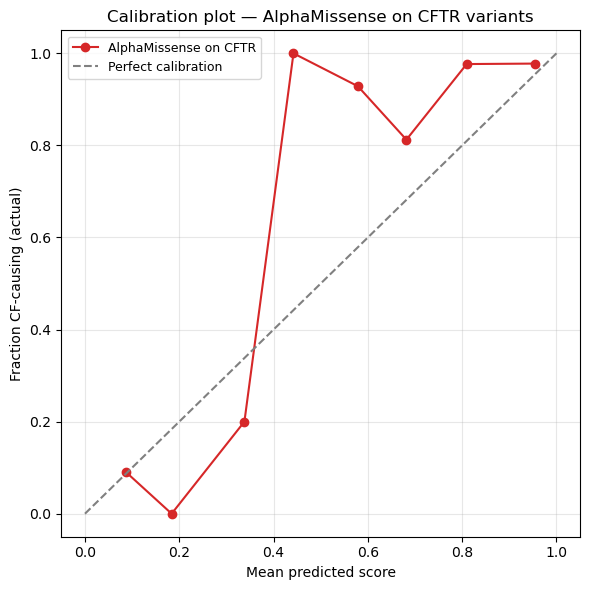

In [40]:
from sklearn.calibration import calibration_curve

binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

prob_true, prob_pred = calibration_curve(binary["label"], binary["am_pathogenicity"], n_bins=8)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", color="#d62728", label="AlphaMissense on CFTR")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
ax.set_xlabel("Mean predicted score")
ax.set_ylabel("Fraction CF-causing (actual)")
ax.set_title("Calibration plot — AlphaMissense on CFTR variants")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("calibration_plot.png", dpi=150, bbox_inches="tight")
plt.show()


In [41]:
# REVEL scores are available as a precomputed flat file
# Filter to chromosome 7 (CFTR) only to keep it manageable
# File: https://zenodo.org/records/7072866/files/revel-v1.3_all_chromosomes.zip

print("REVEL file is ~6GB unzipped.")
print("We only need chr7.")
print()
print("Download and extract chr7 from:")
print("https://zenodo.org/records/7072866/files/revel-v1.3_all_chromosomes.zip")
print()
print("Or we can use the CADD API which needs no download.")
print("CADD has a REST API — one variant at a time, free, no key needed.")
print()
print(f"We have {len(binary)} variants to score.")
print(binary[["variant", "am_variant", "label"]].head())


REVEL file is ~6GB unzipped.
We only need chr7.

Download and extract chr7 from:
https://zenodo.org/records/7072866/files/revel-v1.3_all_chromosomes.zip

Or we can use the CADD API which needs no download.
CADD has a REST API — one variant at a time, free, no key needed.

We have 292 variants to score.
    variant am_variant  label
0  Ser13Phe       S13F      1
1  Arg31Cys       R31C      0
6  Trp57Gly       W57G      1
7  Pro67Leu       P67L      1
9  Arg75Gln       R75Q      0


In [2]:
from sklearn.metrics import matthews_corrcoef
import pandas as pd

result = pd.read_csv("cftr2_results_annotated.csv")
binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

threshold = 0.564
preds = (binary["am_pathogenicity"] >= threshold).astype(int)
mcc = matthews_corrcoef(binary["label"], preds)
print(f"MCC: {mcc:.3f}")


MCC: 0.689
